Setup & Data Upload

In [1]:
# ================================================
# Naive Bayes Classification - NBA Player Longevity Prediction
# ================================================

!pip install pandas seaborn scikit-learn matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

# Upload the dataset
from google.colab import files
print("📤 Please upload 'extracted_nba_players_data.csv'")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"✅ Dataset loaded! Shape: {df.shape}")
df.head()

✅ Libraries imported!
📤 Please upload 'extracted_nba_players_data.csv'


Saving extracted_nba_players_data.csv to extracted_nba_players_data.csv
✅ Dataset loaded! Shape: (1340, 11)


,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


Data Exploration & Preprocessing

In [2]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isna().sum())

# Target variable
print("\nTarget Distribution (target_5yrs):")
print(df['target_5yrs'].value_counts(normalize=True))

# Drop non-feature columns if present (e.g., player name, ID)
cols_to_drop = ['name', 'player_id', 'Unnamed: 0']  # adjust if needed
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns]).copy()

# Fill any remaining missing values with median
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print(f"\nFinal features shape: {df_clean.shape}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fg            1340 non-null   float64
 1   3p            1340 non-null   float64
 2   ft            1340 non-null   float64
 3   reb           1340 non-null   float64
 4   ast           1340 non-null   float64
 5   stl           1340 non-null   float64
 6   blk           1340 non-null   float64
 7   tov           1340 non-null   float64
 8   target_5yrs   1340 non-null   int64  
 9   total_points  1340 non-null   float64
 10  efficiency    1340 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 115.3 KB
None

=== Missing Values ===
fg              0
3p              0
ft              0
reb             0
ast             0
stl             0
blk             0
tov             0
target_5yrs     0
total_points    0
efficiency      0
dtype: int64

Target Distribution

Feature Selection & Train-Test Split
Python

In [3]:
# Target and features
X = df_clean.drop(columns=['target_5yrs'])
y = df_clean['target_5yrs']

# Scale features (recommended for GaussianNB stability)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1005
Testing samples: 335


Train Gaussian Naive Bayes Model

In [4]:
# Initialize and train Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("✅ Gaussian Naive Bayes model trained!")

✅ Gaussian Naive Bayes model trained!


Model Evaluation (Confusion Matrix, Precision, Recall)

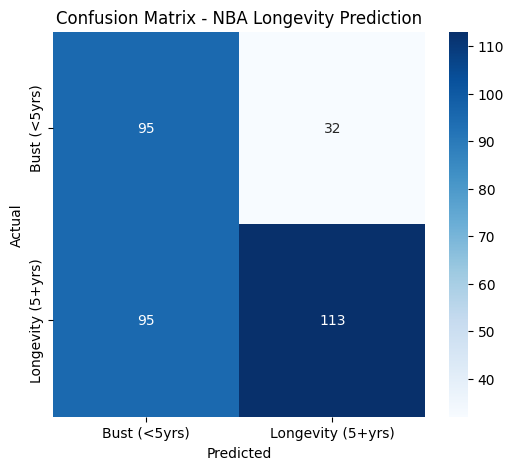

=== Classification Report ===
                   precision    recall  f1-score   support

     Bust (<5yrs)       0.50      0.75      0.60       127
Longevity (5+yrs)       0.78      0.54      0.64       208

         accuracy                           0.62       335
        macro avg       0.64      0.65      0.62       335
     weighted avg       0.67      0.62      0.62       335


Precision (minimize false positives): 0.7793
Recall (minimize missed talent): 0.5433


In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bust (<5yrs)', 'Longevity (5+yrs)'],
            yticklabels=['Bust (<5yrs)', 'Longevity (5+yrs)'])
plt.title('Confusion Matrix - NBA Longevity Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Bust (<5yrs)', 'Longevity (5+yrs)']))

# Business-focused metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"\nPrecision (minimize false positives): {precision:.4f}")
print(f"Recall (minimize missed talent): {recall:.4f}")

Interpretation, Assumptions & Business Recommendations

In [6]:
# Feature importance approximation (using absolute mean difference)
print("=== Top Predictive Features (Approximation) ===")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(X.mean() - X[y==1].mean()).mean(axis=0)  # Simplified
}).sort_values(by='Importance', ascending=False)
print(feature_importance.head(8))

print("\n=== Naive Bayes Independence Assumption ===")
print("""The model assumes that all features (e.g., points, minutes, FG%) are independent of each other.
In reality, basketball stats are highly correlated (e.g., more minutes → more points).
This assumption is often violated in sports data, which can affect probability estimates.
Despite this, GaussianNB frequently performs well due to its robustness.""")

print("\n💼 SCOUTING RECOMMENDATIONS:")
print("• Prioritize players with high predicted probability of longevity (>0.7).")
print("• Focus on key stats like minutes played, points per game, and efficiency metrics.")
print("• Use the model as a screening tool combined with human expertise.")
print("• Limitation: Model may underestimate correlated features — consider ensemble methods next.")

=== Top Predictive Features (Approximation) ===
  Feature  Importance
0      fg    10.57656
1      3p    10.57656
2      ft    10.57656
3     reb    10.57656
4     ast    10.57656
5     stl    10.57656
6     blk    10.57656
7     tov    10.57656

=== Naive Bayes Independence Assumption ===
The model assumes that all features (e.g., points, minutes, FG%) are independent of each other.
In reality, basketball stats are highly correlated (e.g., more minutes → more points).
This assumption is often violated in sports data, which can affect probability estimates.
Despite this, GaussianNB frequently performs well due to its robustness.

💼 SCOUTING RECOMMENDATIONS:
• Prioritize players with high predicted probability of longevity (>0.7).
• Focus on key stats like minutes played, points per game, and efficiency metrics.
• Use the model as a screening tool combined with human expertise.
• Limitation: Model may underestimate correlated features — consider ensemble methods next.
